# Clasificación textual supervisada de publicaciones tipo red social

Este notebook desarrolla un experimento de clasificación supervisada de textos breves en español. El objetivo es predecir la categoría temática de una publicación tipo red social a partir de su descripción y sus hashtags. Las categorías consideradas son: `playa`, `deporte`, `coches`, `cocina`, `videojuegos`, `musica` y `viajes`.

Esto se hace con el fin de crear un algoritmo de recomendación imitando al de las redes sociales más populares actualmente, basándose en la descripción y la categoría de las publicaciones.

El trabajo se plantea como una primera capa de inteligencia artificial para un sistema posterior de recomendación multimodal. En una arquitectura de recomendación, clasificar correctamente el contenido textual permite inferir intereses, agrupar publicaciones por temática y construir señales iniciales de afinidad entre usuarios, contenidos y categorías. Más adelante, se usará este modelo para construir el resultado final del proyecto, el cual implementará el uso de modelos de computer vision.
Esto se hace para conseguir acercarse más al modelo de negocio de las RRSS actuales, en las que las imágenes abundan en las publicaciones más visitadas.


## 1. Introducción y objetivo

El problema abordado consiste en asignar automáticamente una etiqueta temática a cada publicación a partir de información textual. Formalmente, se trata de un problema de clasificación multiclase supervisada: dado un conjunto de ejemplos etiquetados \((x_i, y_i)\), donde \(x_i\) representa el texto de una publicación e \(y_i\) pertenece a un conjunto finito de categorías, se entrena un modelo capaz de estimar la clase más probable para textos no vistos durante el entrenamiento.

El enfoque supervisado es adecuado porque el dataset dispone de una variable objetivo explícita, `categoria`, que actúa como referencia para aprender la relación entre patrones lingüísticos y clases temáticas. A diferencia de un enfoque no supervisado, cuyo objetivo sería descubrir agrupaciones latentes sin etiquetas previas, aquí se busca reproducir una taxonomía definida de antemano. Esto permite evaluar el rendimiento con métricas objetivas y analizar los errores del modelo frente a una verdad conocida.

Desde el punto de vista de un futuro sistema de recomendación, este clasificador puede funcionar como un módulo de enriquecimiento semántico. Cada publicación quedaría asociada a una categoría temática estimada, lo que facilitaría tareas como filtrado por intereses, recomendación basada en contenido, generación de perfiles de usuario y combinación con señales visuales. Por tanto, aunque el experimento se limita al texto, su utilidad se entiende como parte de una arquitectura de recomendación más amplia.


In [1]:
import re
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split

DATA_PATH = Path("data/posts.csv")
EXPECTED_COLUMNS = ["id", "descripcion", "hashtags", "categoria"]
TEST_SIZE = 0.30
RANDOM_STATE = 42
TOP_N_TERMS = 10
TOP_N_WORDS = 20

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25


In [2]:
df = pd.read_csv(DATA_PATH, encoding="utf-8")

actual_columns = list(df.columns)
if set(actual_columns) != set(EXPECTED_COLUMNS):
    raise ValueError(
        "El CSV no tiene el esquema esperado. "
        f"Columnas esperadas: {EXPECTED_COLUMNS}. "
        f"Columnas encontradas: {actual_columns}."
    )

df = df[EXPECTED_COLUMNS].copy()

print(f"Archivo cargado correctamente desde: {DATA_PATH}")
print(f"Número total de registros: {df.shape[0]}")
print(f"Número de variables: {df.shape[1]}")
display(df.head())


Archivo cargado correctamente desde: data\posts.csv
Número total de registros: 5000
Número de variables: 4


,id,descripcion,hashtags,categoria
0,1,Una buena rutina y disciplina es el secreto de...,#maraton #running #gym #fitness,deporte
1,2,NaN,#jetlag,viajes
2,3,Dejando el guiso al chup-chup durante un par d...,#instafood #chef #yummy #casero,cocina
3,4,misma grandes gracias función poner saber unid...,#fitness #workout #gym,deporte
4,5,"Pedaleando por la montaña, menudas cuestas tie...",#gym #workout,deporte


## 2. Análisis exploratorio de datos (EDA)

El análisis exploratorio permite comprobar si el dataset es coherente con el problema que se quiere resolver y detectar posibles limitaciones antes del entrenamiento. En clasificación textual, no basta con revisar el número de registros: también es importante analizar la distribución de clases, la presencia de valores nulos, la longitud de los textos y la señal léxica disponible.

En este caso, cada publicación puede contener dos fuentes textuales: `descripcion` y `hashtags`. La descripción aporta lenguaje natural, mientras que los hashtags tienden a concentrar palabras clave muy informativas. Ambas fuentes se combinarán posteriormente para construir la representación textual del modelo.


In [3]:
print("Valores nulos por columna:")
display(df.isna().sum().to_frame("nulos"))

# La distribución de clases condiciona la lectura de métricas agregadas y el riesgo de sesgo hacia clases mayoritarias.
class_counts = df["categoria"].value_counts().sort_index()
class_distribution = pd.DataFrame(
    {
        "registros": class_counts,
        "porcentaje": (class_counts / len(df) * 100).round(2),
    }
)

print("Distribución de registros por categoría:")
display(class_distribution)


Valores nulos por columna:


,nulos
id,0
descripcion,400
hashtags,750
categoria,0


Distribución de registros por categoría:


,registros,porcentaje
categoria,,
coches,737,14.74
cocina,747,14.94
deporte,705,14.10
musica,746,14.92
playa,657,13.14
viajes,682,13.64
videojuegos,726,14.52


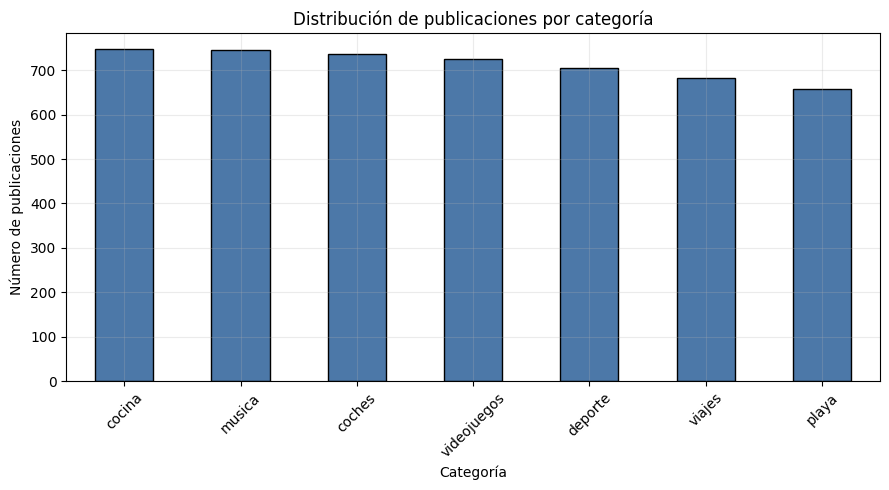

In [4]:
ax = class_counts.sort_values(ascending=False).plot(
    kind="bar",
    color="#4C78A8",
    edgecolor="black",
)
ax.set_title("Distribución de publicaciones por categoría")
ax.set_xlabel("Categoría")
ax.set_ylabel("Número de publicaciones")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


La distribución por categoría es relevante porque un modelo entrenado con clases muy desbalanceadas puede obtener una exactitud aparentemente alta favoreciendo las categorías mayoritarias. En este dataset las clases presentan tamaños relativamente próximos, aunque no idénticos. Por ello, se utilizará una partición estratificada para conservar proporciones similares entre entrenamiento y prueba.


In [5]:
# Se fusionan descripción y hashtags porque ambos son señales textuales; los hashtags pueden ser muy predictivos y sesgar el modelo hacia palabras clave explícitas.
df["texto_original"] = (
    df["descripcion"].fillna("").astype(str).str.strip()
    + " "
    + df["hashtags"].fillna("").astype(str).str.strip()
).str.strip()

# La longitud aproxima la cantidad de evidencia disponible: textos cortos aumentan la varianza de la predicción y la dependencia de términos aislados.
df["longitud_caracteres"] = df["texto_original"].str.len()
df["longitud_palabras"] = df["texto_original"].apply(lambda text: len(text.split()))

display(
    df[["longitud_caracteres", "longitud_palabras"]]
    .describe()
    .round(2)
)

textos_vacios_originales = (df["texto_original"].str.len() == 0).sum()
print(f"Publicaciones sin descripción ni hashtags: {textos_vacios_originales}")


,longitud_caracteres,longitud_palabras
count,5000.00,5000.00
mean,210.26,31.38
std,1400.80,202.07
min,0.00,0.00
25%,57.00,10.00
50%,70.00,11.00
75%,81.00,13.00
max,14092.00,2004.00


Publicaciones sin descripción ni hashtags: 58


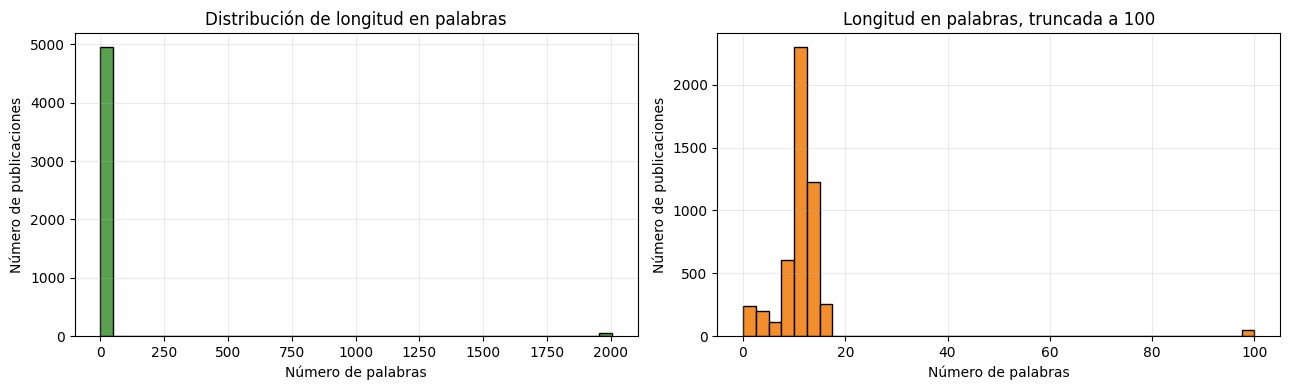

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df["longitud_palabras"].plot(
    kind="hist",
    bins=40,
    color="#59A14F",
    edgecolor="black",
    ax=axes[0],
)
axes[0].set_title("Distribución de longitud en palabras")
axes[0].set_xlabel("Número de palabras")
axes[0].set_ylabel("Número de publicaciones")

# El recorte solo afecta a la visualización; evita que valores extremos oculten la distribución principal de longitudes.
df["longitud_palabras"].clip(upper=100).plot(
    kind="hist",
    bins=40,
    color="#F28E2B",
    edgecolor="black",
    ax=axes[1],
)
axes[1].set_title("Longitud en palabras, truncada a 100")
axes[1].set_xlabel("Número de palabras")
axes[1].set_ylabel("Número de publicaciones")

plt.tight_layout()
plt.show()


La longitud de las publicaciones condiciona la dificultad del problema. Los textos breves contienen menos contexto, por lo que el modelo depende más de palabras clave y hashtags. Además, la presencia de textos extremadamente largos puede introducir ruido si su vocabulario no está alineado con la categoría real. Esta heterogeneidad es una limitación habitual en datos tipo red social.


In [7]:
def preprocesar_texto(texto: str) -> str:
    """Normaliza texto para un modelo clásico basado en bolsa de palabras."""
    # La normalización reduce la dimensionalidad léxica; también puede eliminar señales útiles como puntuación, emojis o marcas de estilo.
    texto = str(texto).lower()
    texto = texto.replace("#", " ")
    texto = re.sub(r"[^a-záéíóúüñ0-9\s]", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto


# El modelo posterior no aprende semántica contextual, sino asociaciones entre tokens normalizados y categorías.
df["texto_limpio"] = df["texto_original"].apply(preprocesar_texto)
df["longitud_limpia_palabras"] = df["texto_limpio"].apply(lambda text: len(text.split()))

textos_vacios_limpios = (df["texto_limpio"].str.len() == 0).sum()
print(f"Publicaciones sin señal textual tras el preprocesamiento: {textos_vacios_limpios}")

display(df[["descripcion", "hashtags", "texto_original", "texto_limpio"]].head(8))


Publicaciones sin señal textual tras el preprocesamiento: 58


,descripcion,hashtags,texto_original,texto_limpio
0,Una buena rutina y disciplina es el secreto de...,#maraton #running #gym #fitness,Una buena rutina y disciplina es el secreto de...,una buena rutina y disciplina es el secreto de...
1,NaN,#jetlag,#jetlag,jetlag
2,Dejando el guiso al chup-chup durante un par d...,#instafood #chef #yummy #casero,Dejando el guiso al chup-chup durante un par d...,dejando el guiso al chup chup durante un par d...
3,misma grandes gracias función poner saber unid...,#fitness #workout #gym,misma grandes gracias función poner saber unid...,misma grandes gracias función poner saber unid...
4,"Pedaleando por la montaña, menudas cuestas tie...",#gym #workout,"Pedaleando por la montaña, menudas cuestas tie...",pedaleando por la montaña menudas cuestas tien...
5,"Desconectando en la naturaleza de Mauritania, ...",NaN,"Desconectando en la naturaleza de Mauritania, ...",desconectando en la naturaleza de mauritania n...
6,NaN,NaN,,
7,Apurando frenadas como si no hubiera un mañana.,#racing #drifting #cars,Apurando frenadas como si no hubiera un mañana...,apurando frenadas como si no hubiera un mañana...


,palabra,frecuencia
0,hoy,373
1,sol,355
2,costa,334
3,mar,329
4,arena,312
5,verano,307
6,está,296
7,temazo,285
8,festival,280
9,drifting,277


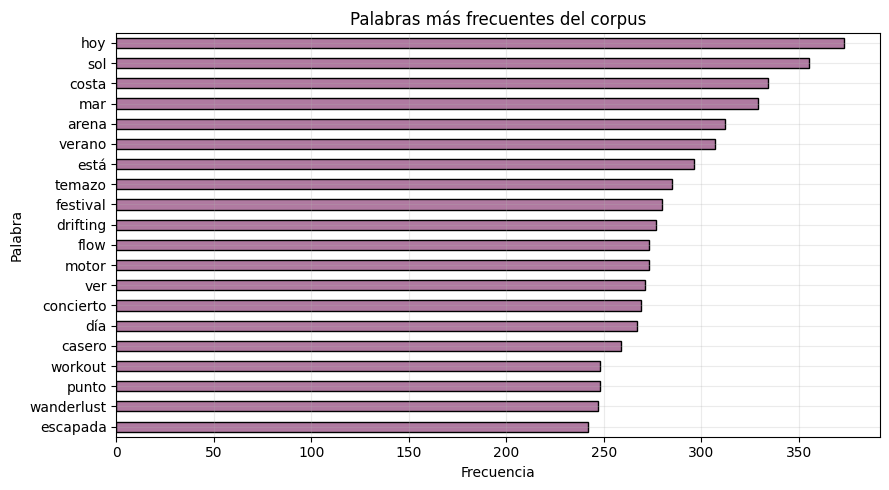

In [8]:
SPANISH_STOPWORDS = {
    "a", "al", "algo", "ante", "antes", "como", "con", "contra", "cual", "cuando",
    "de", "del", "desde", "donde", "durante", "e", "el", "ella", "ellas", "ellos",
    "en", "entre", "era", "eran", "es", "esa", "esas", "ese", "eso", "esos", "esta",
    "estaba", "estaban", "estado", "estan", "estar", "estas", "este", "esto", "estos",
    "fue", "ha", "hay", "he", "la", "las", "le", "les", "lo", "los", "mas", "me",
    "mi", "mis", "mucho", "muy", "ni", "no", "nos", "o", "para", "pero", "por",
    "que", "se", "sin", "sobre", "su", "sus", "tambien", "tan", "te", "tiene",
    "todo", "tras", "tu", "un", "una", "unas", "uno", "unos", "y", "ya"
}

# Este análisis explora el vocabulario global, pero no se utiliza para ajustar el modelo y por tanto no introduce fuga de información.
tokens = []
for texto in df["texto_limpio"]:
    tokens.extend(
        token for token in texto.split()
        if token not in SPANISH_STOPWORDS and len(token) > 2
    )

frecuencias_globales = pd.DataFrame(
    Counter(tokens).most_common(TOP_N_WORDS),
    columns=["palabra", "frecuencia"],
)

display(frecuencias_globales)

ax = frecuencias_globales.sort_values("frecuencia").plot(
    kind="barh",
    x="palabra",
    y="frecuencia",
    legend=False,
    color="#B07AA1",
    edgecolor="black",
)
ax.set_title("Palabras más frecuentes del corpus")
ax.set_xlabel("Frecuencia")
ax.set_ylabel("Palabra")
plt.tight_layout()
plt.show()


El análisis de palabras frecuentes ayuda a comprobar si existen términos temáticamente informativos y si el corpus contiene ruido. En un dataset de publicaciones sociales es esperable encontrar vocabulario muy específico, como términos asociados a deporte, cocina, viajes o videojuegos, junto con palabras más generales. Esta observación justifica el uso de TF-IDF, ya que esta técnica reduce el peso relativo de términos frecuentes en muchos documentos y destaca palabras más características de cada publicación.

Como limitación, el EDA también muestra que existen registros sin señal textual tras combinar descripción y hashtags. Estos casos no aportan información para un clasificador textual y, si se mantienen en entrenamiento, obligan al modelo a aprender a partir de vectores vacíos o poco informativos. Por ello, se conservarán en el análisis descriptivo del dataset, pero se excluirán de la fase de modelado.


## 3. Metodología

La metodología sigue un flujo clásico de aprendizaje supervisado para texto: preparación de la variable de entrada, eliminación de registros sin información textual, separación en entrenamiento y prueba, vectorización TF-IDF y entrenamiento de un clasificador lineal.

La separación entre entrenamiento y prueba se realiza antes de ajustar el vectorizador. Esta decisión evita fuga de información, ya que el vocabulario y las ponderaciones IDF deben aprenderse únicamente con los datos de entrenamiento. El conjunto de prueba debe simular datos no vistos para estimar de forma honesta la capacidad de generalización del modelo.


In [9]:
# Se excluyen textos sin señal observable; esto mejora el entrenamiento, pero puede sobreestimar el rendimiento si en producción aparecen entradas vacías.
df_modelo = df[df["texto_limpio"].str.len() > 0].copy()

print(f"Registros originales: {len(df)}")
print(f"Registros utilizados para modelado: {len(df_modelo)}")
print(f"Registros excluidos por texto vacío: {len(df) - len(df_modelo)}")
print(f"Textos vacíos en df_modelo: {(df_modelo['texto_limpio'].str.len() == 0).sum()}")

X = df_modelo["texto_limpio"]
y = df_modelo["categoria"]


Registros originales: 5000
Registros utilizados para modelado: 4942
Registros excluidos por texto vacío: 58
Textos vacíos en df_modelo: 0


In [10]:
# La partición separa ajuste y evaluación; el test actúa como aproximación a datos no vistos.
# stratify conserva la proporción de clases y random_state fija la muestra para hacer reproducible la comparación experimental.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

split_distribution = pd.DataFrame(
    {
        "train": y_train.value_counts().sort_index(),
        "test": y_test.value_counts().sort_index(),
    }
)
split_distribution["train_%"] = (split_distribution["train"] / len(y_train) * 100).round(2)
split_distribution["test_%"] = (split_distribution["test"] / len(y_test) * 100).round(2)

display(split_distribution)


,train,test,train_%,test_%
categoria,,,,
coches,510,219,14.74,14.77
cocina,515,221,14.89,14.90
deporte,491,210,14.19,14.16
musica,518,222,14.98,14.97
playa,454,195,13.13,13.15
viajes,468,200,13.53,13.49
videojuegos,503,216,14.54,14.57


El parámetro `stratify=y` mantiene en entrenamiento y prueba proporciones similares de cada categoría. Esto es importante porque, incluso con clases relativamente equilibradas, una partición aleatoria simple podría dejar alguna clase infrarepresentada en el conjunto de prueba y distorsionar la evaluación.

El valor `random_state=42` fija la semilla aleatoria. Su función no es mejorar el modelo, sino garantizar reproducibilidad: cualquier persona que ejecute el notebook con los mismos datos obtendrá la misma partición y podrá comparar resultados de forma consistente.


In [11]:
# TF-IDF pondera frecuencia local e inversa documental: frente a conteos simples, penaliza términos comunes y resalta vocabulario discriminativo.
vectorizer = TfidfVectorizer()
# fit_transform aprende vocabulario e IDF solo en train; hacerlo sobre todo el corpus filtraría información del test.
X_train_tfidf = vectorizer.fit_transform(X_train)
# En test se reutilizan vocabulario e IDF aprendidos; términos nuevos no influyen en la predicción.
X_test_tfidf = vectorizer.transform(X_test)

print(f"Documentos de entrenamiento: {X_train_tfidf.shape[0]}")
print(f"Documentos de prueba: {X_test_tfidf.shape[0]}")
print(f"Tamaño del vocabulario aprendido: {X_train_tfidf.shape[1]}")


Documentos de entrenamiento: 3459
Documentos de prueba: 1483
Tamaño del vocabulario aprendido: 1597


TF-IDF transforma cada texto en un vector numérico. La frecuencia de término mide cuántas veces aparece una palabra en un documento, mientras que el componente IDF reduce la importancia de palabras que aparecen en muchos documentos y, por tanto, tienen menor capacidad discriminativa.

Esta representación es adecuada como baseline en clasificación textual porque es eficiente, interpretable y suele ofrecer buenos resultados cuando las categorías están asociadas a vocabularios diferenciados. Además, no requiere modelos preentrenados ni grandes volúmenes de datos, lo cual resulta coherente con una primera aproximación experimental dentro del TFM.


In [12]:
# El clasificador lineal aprende pesos por término para separar clases en el espacio TF-IDF, no significados lingüísticos profundos.
model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
# fit optimiza los coeficientes minimizando una pérdida logística regularizada sobre los ejemplos etiquetados de entrenamiento.
model.fit(X_train_tfidf, y_train)

print("Modelo entrenado correctamente.")
print(f"Clases aprendidas: {list(model.classes_)}")


Modelo entrenado correctamente.
Clases aprendidas: ['coches', 'cocina', 'deporte', 'musica', 'playa', 'viajes', 'videojuegos']


Logistic Regression es un clasificador lineal que estima, para cada clase, una combinación ponderada de las características de entrada. En este caso, las características son términos ponderados mediante TF-IDF. Aunque su nombre incluya la palabra “regression”, en este contexto se utiliza para clasificación multiclase.

Una ventaja de este modelo es su interpretabilidad: los coeficientes asociados a cada término indican cuánto contribuye ese término a aumentar la puntuación de una clase frente a las demás. Por ejemplo, si una palabra tiene un coeficiente alto y positivo para `cocina`, su presencia ponderada en un texto empuja la predicción hacia esa categoría. Esta propiedad permite no solo evaluar el rendimiento, sino también inspeccionar qué señales lingüísticas está utilizando el modelo.


In [13]:
# Los coeficientes conectan cada término TF-IDF con el logit de una clase; valores positivos altos aumentan su evidencia relativa.
feature_names = vectorizer.get_feature_names_out()
top_terms_rows = []

for class_index, categoria in enumerate(model.classes_):
    # Los términos superiores muestran señales aprendidas, aunque pueden capturar artefactos del dataset y no causalidad temática.
    top_indices = model.coef_[class_index].argsort()[-TOP_N_TERMS:][::-1]
    for posicion, term_index in enumerate(top_indices, start=1):
        top_terms_rows.append(
            {
                "categoria": categoria,
                "posicion": posicion,
                "termino": feature_names[term_index],
                "coeficiente": round(float(model.coef_[class_index][term_index]), 4),
            }
        )

top_terms_df = pd.DataFrame(top_terms_rows)
display(top_terms_df)


,categoria,posicion,termino,coeficiente
0,coches,1,drifting,3.0023
1,coches,2,motor,2.9977
2,coches,3,velocidad,2.7528
3,coches,4,racing,2.4485
4,coches,5,cargram,2.3167
...,...,...,...,...
65,videojuegos,6,setup,2.2329
66,videojuegos,7,streamer,2.1396
67,videojuegos,8,partida,1.7859
68,videojuegos,9,unos,1.5871


## 4. Evaluación

La evaluación se realiza exclusivamente sobre el conjunto de prueba. Este conjunto no ha participado ni en el aprendizaje del vocabulario TF-IDF ni en el ajuste de los coeficientes de Logistic Regression. Por tanto, sus resultados ofrecen una estimación más realista del comportamiento esperado ante publicaciones no vistas.

Se utilizan métricas globales y por clase. En problemas multiclase, las métricas macro son especialmente útiles porque calculan primero el resultado de cada clase y después promedian, asignando el mismo peso a todas las categorías independientemente de su tamaño.


In [14]:
# Las predicciones se generan únicamente con representaciones del test transformadas con parámetros aprendidos en train.
y_pred = model.predict(X_test_tfidf)

# Accuracy mide acierto global; puede ser optimista si una clase domina o si los errores minoritarios quedan ocultos.
accuracy = accuracy_score(y_test, y_pred)
# Precision_macro penaliza falsos positivos por clase dando el mismo peso a todas las categorías.
precision_macro = precision_score(y_test, y_pred, average="macro", zero_division=0)
# Recall_macro mide la capacidad de recuperar cada clase real; es sensible a clases que el modelo ignora.
recall_macro = recall_score(y_test, y_pred, average="macro", zero_division=0)
# F1_macro resume precision y recall por clase; puede ocultar qué categoría concreta falla si no se revisa el informe detallado.
f1_macro = f1_score(y_test, y_pred, average="macro", zero_division=0)

metricas_globales = pd.DataFrame(
    {
        "métrica": ["accuracy", "precision_macro", "recall_macro", "f1_macro"],
        "valor": [accuracy, precision_macro, recall_macro, f1_macro],
    }
)
metricas_globales["valor"] = metricas_globales["valor"].round(4)

display(metricas_globales)

print("Classification report:")
# El informe por clase permite detectar sesgos que las métricas globales pueden promediar en exceso.
print(classification_report(y_test, y_pred, zero_division=0))


,métrica,valor
0,accuracy,0.9865
1,precision_macro,0.9875
2,recall_macro,0.9867
3,f1_macro,0.9869


Classification report:
              precision    recall  f1-score   support

      coches       0.94      1.00      0.97       219
      cocina       1.00      0.95      0.98       221
     deporte       0.98      1.00      0.99       210
      musica       1.00      0.99      0.99       222
       playa       1.00      0.99      1.00       195
      viajes       1.00      0.98      0.99       200
 videojuegos       1.00      0.99      1.00       216

    accuracy                           0.99      1483
   macro avg       0.99      0.99      0.99      1483
weighted avg       0.99      0.99      0.99      1483



La `accuracy` representa la proporción total de predicciones correctas. La `precision` indica, para una clase, qué proporción de las predicciones realizadas como esa clase eran realmente correctas. El `recall` mide qué proporción de los casos reales de una clase fueron recuperados por el modelo. El `F1-score` combina precision y recall mediante su media armónica, por lo que resulta útil cuando se busca un equilibrio entre falsos positivos y falsos negativos.

El promedio macro evita que las clases con más ejemplos dominen la lectura agregada. En este proyecto es una elección apropiada porque todas las categorías tienen relevancia conceptual dentro del sistema de clasificación, no solo las más frecuentes.


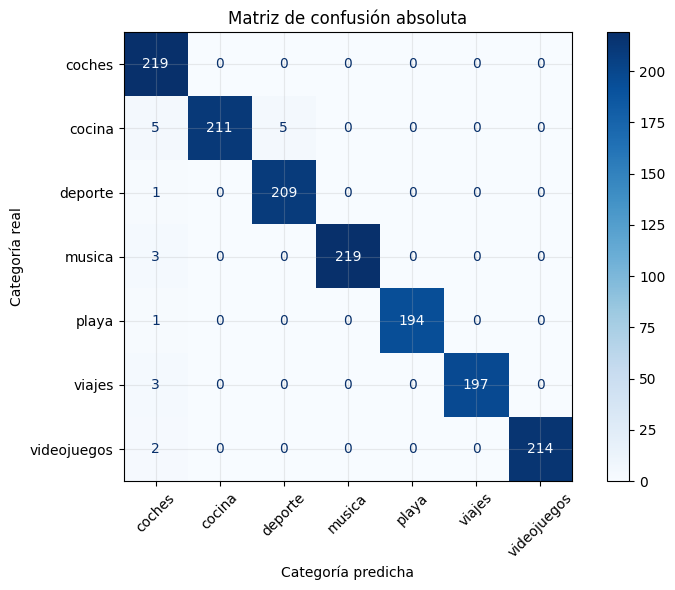

In [15]:
# Se fija el orden de etiquetas para que filas y columnas de las matrices sean comparables entre ejecuciones.
labels = list(model.classes_)

fig, ax = plt.subplots(figsize=(8, 6))
# Filas = clase real, columnas = clase predicha; la diagonal son aciertos y la zona externa son confusiones específicas.
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    labels=labels,
    display_labels=labels,
    cmap="Blues",
    xticks_rotation=45,
    ax=ax,
    colorbar=True,
)
ax.set_title("Matriz de confusión absoluta")
ax.set_xlabel("Categoría predicha")
ax.set_ylabel("Categoría real")
plt.tight_layout()
plt.show()


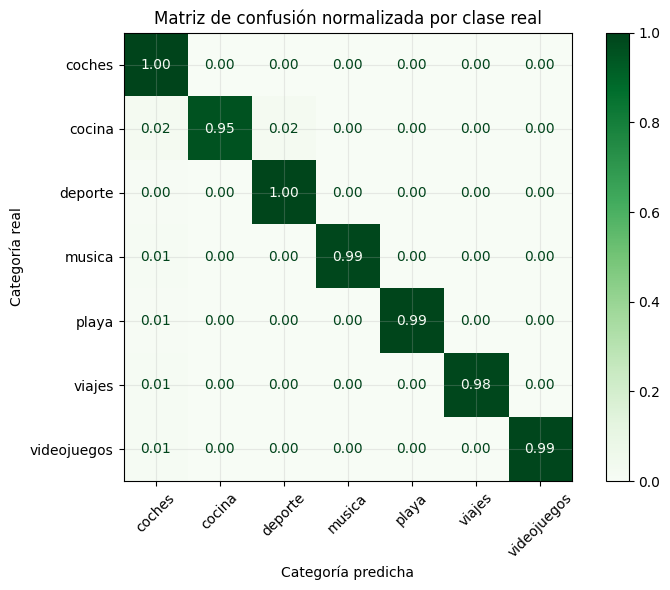

In [16]:
fig, ax = plt.subplots(figsize=(8, 6))
# normalize="true" convierte cada fila en proporciones: interpreta los errores condicionados a cada clase real.
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    labels=labels,
    display_labels=labels,
    normalize="true",
    values_format=".2f",
    cmap="Greens",
    xticks_rotation=45,
    ax=ax,
    colorbar=True,
)
ax.set_title("Matriz de confusión normalizada por clase real")
ax.set_xlabel("Categoría predicha")
ax.set_ylabel("Categoría real")
plt.tight_layout()
plt.show()


La matriz de confusión debe leerse con filas como clases reales y columnas como clases predichas. Los valores de la diagonal principal son aciertos. Los valores fuera de la diagonal representan errores: por ejemplo, una celda en la fila `cocina` y la columna `deporte` indica publicaciones reales de cocina clasificadas como deporte.

La matriz absoluta muestra el número de casos, mientras que la matriz normalizada por clase real expresa proporciones dentro de cada fila. Esta segunda versión facilita comparar clases con distinto número de ejemplos, ya que cada fila se interpreta como distribución porcentual de las predicciones realizadas para una clase real.


## 5. Análisis de resultados

Además de presentar métricas, es necesario interpretar qué está funcionando, dónde se producen errores y por qué. En modelos basados en bolsa de palabras, los aciertos suelen depender de la existencia de términos muy característicos de cada categoría. Los errores aparecen cuando el texto es corto, ambiguo, contiene vocabulario compartido entre clases o incluye ruido no relacionado con la etiqueta.


In [17]:
# El support contextualiza la estabilidad de cada métrica: con pocos ejemplos, precision y recall fluctúan más.
report_dict = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report_dict).T
class_report_df = report_df.loc[labels, ["precision", "recall", "f1-score", "support"]].copy()
class_report_df[["precision", "recall", "f1-score"]] = class_report_df[
    ["precision", "recall", "f1-score"]
].round(4)
class_report_df["support"] = class_report_df["support"].astype(int)

display(class_report_df.sort_values("f1-score", ascending=False))

best_classes = class_report_df.sort_values("f1-score", ascending=False).head(3)
print("Clases con mayor F1-score:")
for categoria, row in best_classes.iterrows():
    print(f"- {categoria}: F1={row['f1-score']:.4f}, precision={row['precision']:.4f}, recall={row['recall']:.4f}")


,precision,recall,f1-score,support
playa,1.0000,0.9949,0.9974,195
videojuegos,1.0000,0.9907,0.9953,216
musica,1.0000,0.9865,0.9932,222
viajes,1.0000,0.9850,0.9924,200
deporte,0.9766,0.9952,0.9858,210
cocina,1.0000,0.9548,0.9769,221
coches,0.9359,1.0000,0.9669,219


Clases con mayor F1-score:
- playa: F1=0.9974, precision=1.0000, recall=0.9949
- videojuegos: F1=0.9953, precision=1.0000, recall=0.9907
- musica: F1=0.9932, precision=1.0000, recall=0.9865


In [ ]:
# Extraer solo la diagonal externa ayuda a identificar patrones sistemáticos de solapamiento léxico entre categorías.
cm = confusion_matrix(y_test, y_pred, labels=labels)
confusion_rows = []

for real_index, real_label in enumerate(labels):
    for pred_index, pred_label in enumerate(labels):
        if real_index != pred_index and cm[real_index, pred_index] > 0:
            confusion_rows.append(
                {
                    "categoria_real": real_label,
                    "categoria_predicha": pred_label,
                    "casos": int(cm[real_index, pred_index]),
                }
            )

confusiones_df = pd.DataFrame(confusion_rows).sort_values("casos", ascending=False)
display(confusiones_df)


En la ejecución actual, el rendimiento global es alto: la accuracy se sitúa aproximadamente en `0.987` y el F1 macro en torno a `0.987`. Esto indica que el modelo generaliza bien sobre el conjunto de prueba y que el rendimiento no depende únicamente de una clase mayoritaria.

Las clases con mejores resultados tienden a ser aquellas con vocabulario más específico. Categorías como `videojuegos`, `musica`, `playa`, `viajes` o `deporte` suelen contener términos muy distintivos, como referencias a juegos, conciertos, playa, rutas o actividad física. Esta separación léxica favorece a TF-IDF y a Logistic Regression, porque ambos métodos explotan diferencias en la presencia y ponderación de palabras.

Las confusiones observadas se concentran en pocos casos. Destacan errores como `cocina` clasificada como `deporte`, `cocina` clasificada como `coches` y `viajes` clasificada como `coches`. Estas confusiones pueden explicarse por solapamiento léxico, publicaciones demasiado breves, hashtags poco específicos o textos generados con vocabulario no completamente alineado con la etiqueta. Por ejemplo, una publicación que combine una ruta, una parada gastronómica o términos generales de actividad puede activar señales de varias categorías.

Esta lectura está directamente relacionada con las limitaciones del enfoque Bag-of-Words. TF-IDF representa documentos como conjuntos ponderados de términos, pero no modela de forma profunda el orden de las palabras, la semántica contextual ni relaciones complejas entre conceptos. Por tanto, dos textos con vocabulario parecido pueden quedar próximos aunque su significado global sea distinto.


## 6. Conclusiones

El experimento demuestra que una arquitectura clásica basada en TF-IDF y Logistic Regression puede resolver con alto rendimiento una tarea de clasificación temática de publicaciones tipo red social. Tras eliminar registros sin señal textual, el modelo alcanza una accuracy aproximada de `0.987` y un F1 macro aproximado de `0.987`, lo que refleja un comportamiento equilibrado entre categorías.

Desde el punto de vista metodológico, el uso de una partición estratificada ha permitido evaluar el modelo manteniendo proporciones comparables de cada clase en entrenamiento y prueba. La elección de TF-IDF se justifica por su capacidad para representar textos breves mediante términos discriminativos, mientras que Logistic Regression aporta una solución eficiente, reproducible e interpretable. La inspección de coeficientes confirma que el modelo aprende asociaciones coherentes entre palabras clave y categorías.

No obstante, el rendimiento debe interpretarse de forma crítica. El dataset presenta un grado de control elevado y contiene categorías con vocabularios relativamente diferenciados, por lo que los resultados podrían ser más bajos en un entorno real con lenguaje más ambiguo, ironía, errores ortográficos, mezclas temáticas o publicaciones sin hashtags. Además, el enfoque Bag-of-Words no captura adecuadamente semántica contextual ni relaciones entre palabras, lo que limita su capacidad ante textos complejos.

Como mejoras futuras, se podrían incorporar n-gramas para capturar expresiones compuestas, comparar Logistic Regression con modelos como Linear SVM, ajustar hiperparámetros mediante validación cruzada o utilizar embeddings semánticos procedentes de modelos transformer. Estas alternativas permitirían representar mejor similitudes semánticas y reducir errores cuando diferentes categorías comparten vocabulario.

Finalmente, este clasificador textual constituye una base sólida para una futura fase multimodal del TFM. En un sistema de recomendación más completo, las predicciones textuales podrían combinarse con características visuales extraídas mediante computer vision. De esta forma, el sistema no dependería únicamente del texto escrito por el usuario, sino que integraría señales procedentes tanto del contenido textual como de las imágenes asociadas a cada publicación.
